# Analysisng Models

## Looking for differences in predictions

In [1]:
import pandas as pd 
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from model_evaluation import EvalConfig, EvalModel
import os
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

input_csv = "Data/features_30_sec.csv" 
drop_cols = ['filename', 'length', 'label'] 
target_col = 'label'

In [2]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

pipelines = [
    Pipeline([('rf', RandomForestClassifier()]),
    Pipeline([
        ('et', ExtraTreesClassifier(n_estimators=100))
    ]),
    Pipeline([
        ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3))
    ]),
    Pipeline([
        ('ada', AdaBoostClassifier(n_estimators=50))
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(C=10, gamma="scale")),
    ]),
    Pipeline([
        ("scaler", StandardScaler()),
        ("lsvc", LinearSVC(C=1.0, dual="auto", max_iter=2000))
    ]),

    Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(max_iter=1000, solver='lbfgs'))
    ]),

    Pipeline([
        ('scaler', StandardScaler()),
        ('sgd', SGDClassifier(loss='hinge', penalty='l2', max_iter=1000, tol=1e-3))
    ]),

    Pipeline([
        ("scaler", StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5))
    ]),

    Pipeline([
        ("scaler", StandardScaler()), 
        ('gnb', GaussianNB())
    ]),

    Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', solver='adam'))
    ]),

    Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('svm_pca', SVC(C=10, kernel='rbf'))
    ])

]

In [3]:
temp_csv_name = "temp_csv_data.csv"
df_full = pd.read_csv(input_csv)

In [4]:
def format_labels(numeric_labels, encoder):
    label_names = encoder.inverse_transform(numeric_labels)
    return [f"{num} ({name})" for num, name in zip(numeric_labels, label_names)]

In [17]:
from collections import Counter 

model_counts = Counter()
results = []
all_predictions = {}
class_performance = []
le = LabelEncoder()

# df_full[target_col] = le.fit_transform(df_full[target_col])

for pipeline in pipelines:
    curr_df = df_full.copy()
    base_name = pipeline.steps[-1][1].__class__.__name__
    model_counts[base_name] += 1
    if model_counts[base_name] > 1:
        model_name = f"{base_name}_{model_counts[base_name]}"
    else:
        model_name = base_name
    curr_df.to_csv(temp_csv_name, index=False)

    config = EvalConfig(
        train_path=temp_csv_name,
        pipeline=pipeline,
        drop_cols=drop_cols,
        target_col=target_col,
        random_state=1231
    )

    eval_model = EvalModel(config)
    res = eval_model.evaluate()
    print(model_name)
    # eval_model.plot_eval()
    acc = res['report']['accuracy']
    report_dict = res['report']
    for key, metrics in report_dict.items():
        if isinstance(metrics, dict):
            if key.isdigit():
                numeric_key = int(key)
                try:
                    class_name = le.inverse_transform([numeric_key])[0]
                    full_label = f"{key} ({class_name})"
                except:
                    full_label = f"Class {key}"
            else:
                full_label = key

            class_performance.append({
                "Model": model_name,
                "Class": full_label,
                "Recall": metrics['recall'],    
            })
    if 'True Label' not in all_predictions:
        # y_test_formatted = format_labels(eval_model.y_test.values, le)
        all_predictions['True Label'] = eval_model.y_pred

    # y_pred_formatted = format_labels(eval_model.y_pred, le)
    all_predictions[model_name] =eval_model.y_pred

    results.append({
        "Model": model_name,
        "Accuracy": acc,
    })
    
if os.path.exists(temp_csv_name):
    os.remove(temp_csv_name)

RandomForestClassifier
ExtraTreesClassifier
GradientBoostingClassifier
AdaBoostClassifier
SVC
LinearSVC
LogisticRegression
SGDClassifier
KNeighborsClassifier
GaussianNB
MLPClassifier
SVC_2


In [18]:
df_predictions = pd.DataFrame(all_predictions)
print(pd.DataFrame(results))
print(df_predictions)

                         Model  Accuracy
0       RandomForestClassifier     0.710
1         ExtraTreesClassifier     0.730
2   GradientBoostingClassifier     0.695
3           AdaBoostClassifier     0.485
4                          SVC     0.745
5                    LinearSVC     0.710
6           LogisticRegression     0.685
7                SGDClassifier     0.650
8         KNeighborsClassifier     0.660
9                   GaussianNB     0.550
10               MLPClassifier     0.760
11                       SVC_2     0.715
    True Label RandomForestClassifier ExtraTreesClassifier  \
0    classical              classical            classical   
1         rock                   rock                 rock   
2       hiphop                 hiphop               hiphop   
3        disco                  disco               hiphop   
4       reggae                 reggae                 rock   
..         ...                    ...                  ...   
195       rock                   

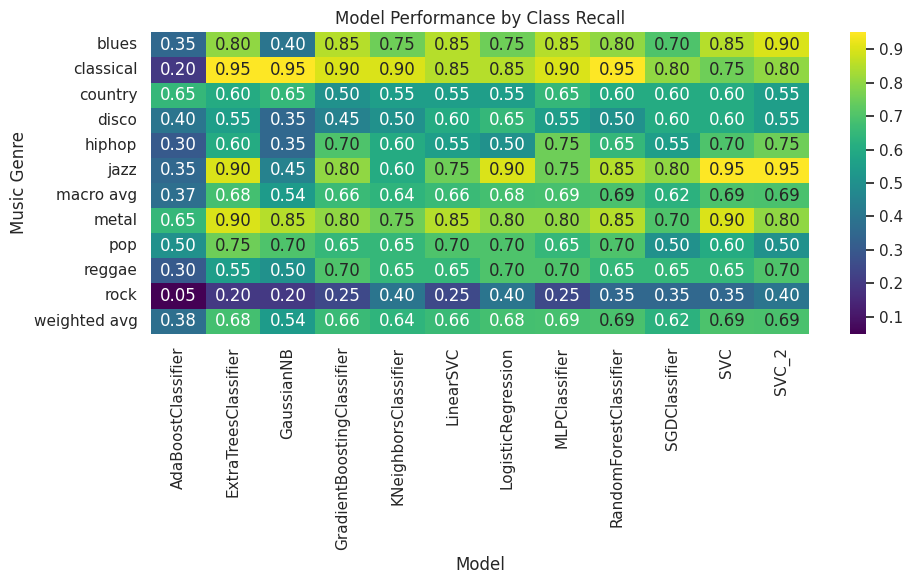

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
df_perf = pd.DataFrame(class_performance)
heatmap_data = df_perf.pivot(index="Class",columns="Model", values="Recall")

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap="viridis", fmt=".2f")
plt.title("Model Performance by Class Recall")
plt.ylabel("Music Genre")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

results_cv = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Cross-Validation")

for pipeline in pipelines:
    if 'classifier' in pipeline.named_steps:
        model_name = pipeline.named_steps['classifier'].__class__.__name__
    else:
        model_name = pipeline.steps[-1][1].__class__.__name__
    
    scores = cross_val_score(pipeline, df_full.drop(drop_cols, axis=1), df_full[target_col], cv=cv, scoring='accuracy')
    
    results_cv.append({
        "Model": model_name,
        "Mean Accuracy": scores.mean(),      
        "Std Dev": scores.std(),              
        "Min Score": scores.min(),
        "Max Score": scores.max()
    })

df_cv_results = pd.DataFrame(results_cv).sort_values(by="Mean Accuracy", ascending=False)
print(df_cv_results)

Cross-Validation
                         Model  Mean Accuracy   Std Dev  Min Score  Max Score
10               MLPClassifier          0.737  0.021817      0.700      0.765
11                         SVC          0.731  0.031369      0.695      0.765
4                          SVC          0.730  0.028983      0.700      0.770
1         ExtraTreesClassifier          0.722  0.031875      0.685      0.775
6           LogisticRegression          0.707  0.016912      0.685      0.730
0       RandomForestClassifier          0.703  0.033556      0.660      0.760
2   GradientBoostingClassifier          0.700  0.035637      0.670      0.755
5                    LinearSVC          0.694  0.028879      0.660      0.735
8         KNeighborsClassifier          0.677  0.026571      0.650      0.725
7                SGDClassifier          0.647  0.030919      0.590      0.675
9                   GaussianNB          0.533  0.032342      0.505      0.575
3           AdaBoostClassifier          0.403  